# Metaheurística Inspirada en Ecolocalización de Murciélagos

## Parte 1: Definición del Problema

El **problema del laberinto** es un clásico de optimización: dado un mapa 2D con paredes y caminos libres, encontrar el camino más corto desde un punto de inicio hacia el objetivo, evitando obstáculos. En este caso:
- Mapa de 30×30 celdas
- Probabilidad de paredes: 28%
- Inicio: esquina superior izquierda
- Objetivo: celda aleatoria
- Restricción: solo movimientos orthogonales (N, S, E, O)


## Parte 2: La Metaheurística "Echo" (Ecolocalización)

### La Metáfora: Murciélagos en Cuevas

Los murciélagos navegan cuevas oscuras mediante **ecolocalización**:
1. Emiten ultrasonidos (15-200 kHz) que rebotan en obstáculos
2. Escuchan el eco para detectar distancia y dirección
3. Exploración limitada por profundidad del sonido

### Cómo Trasladamos Esto al Laberinto

**Echo Algorithm**:
- Cada "ronda" realiza una búsqueda en profundidad acotada (como pulsos ultrasónicos)
- Cuando se agota la profundidad → nodo frontera (eco detectado)
- La siguiente ronda inicia desde esos nodos frontera (reagrupación)
- Se repite hasta encontrar objetivo o agotar espacio

**Balance Exploración-Explotación**:
- **Exploración**: Búsqueda local limitada en cada ronda (evita profundidad infinita)
- **Explotación**: Usa puntos frontera descubiertos (no reinicia de cero)


## Parte 3: Método Base para Comparación

### Backtracking (Método Clásico)

Búsqueda exhaustiva sin límites de profundidad:
- Explora todas las direcciones (derecha, frente, izquierda)
- Cuando se agota → **backtrack** (retroceso) completo
- Garantiza solución si existe
- **Limitación**: puede explorar mucho más espacio que Echo

### Benchmark: Comparación de Rendimiento

Se ejecutarán **5 corridas exitosas** de cada método:
- En mapas diferentes (si no hay solución, se descarta)
- Sin interfaz gráfica (velocidad pura)
- Métricas: tiempo de ejecución, pasos, celdas visitadas
- Resultado: tabla comparativa en CSV

**Hipótesis**: Echo debería ser más rápido (limita exploración) pero podría usar más pasos en el camino.


In [10]:
import tkinter as tk
import random
import time
from threading import Thread
import sys


In [11]:
# ─────────────────────────────────────────────
#  CLASE PRINCIPAL DE BACKTRACKING
# ─────────────────────────────────────────────
 
class Backtracking:
    """
    Resuelve un laberinto con backtracking usando direcciones RELATIVAS
    al movimiento del agente:
        1. Derecha relativa
        2. Enfrente (misma dirección de viaje)
        3. Izquierda relativa
        4. Si ninguna funciona → backtrack hasta la casilla más cercana
           en el camino que tenga opciones sin visitar.
 
    El mapa usa:
        0 → libre  |  1 → pared  |  2 → objetivo
 
    Orientaciones absolutas:
        0 = Este (→)   1 = Sur (↓)   2 = Oeste (←)   3 = Norte (↑)
    """
 
    # Vectores (dr, dc) por orientación absoluta
    FACING_VEC = [
        ( 0,  1),   # 0 Este  →
        ( 1,  0),   # 1 Sur   ↓
        ( 0, -1),   # 2 Oeste ←
        (-1,  0),   # 3 Norte ↑
    ]
 
    # Giros relativos: derecha(+1), frente(0), izquierda(-1)
    REL_TURNS = [+1, 0, -1]
 
    # Orientación inicial: mirando al Este (→)
    INITIAL_FACING = 0
 
    def __init__(self, grid, start):
        self.grid    = grid
        self.rows    = len(grid)
        self.cols    = len(grid[0])
        self.start   = start
        self.path    = []
        self.visited = set()
        self.steps   = []
        self._found  = False
 
    def solve(self):
        self._found = False
        self.path.clear()
        self.visited.clear()
        self.steps.clear()
        self._solve_iterative()
        return self._found
 
    def _solve_iterative(self):
        r0, c0 = self.start
        if not (0 <= r0 < self.rows and 0 <= c0 < self.cols):
            return
        if self.grid[r0][c0] == 1:
            return
 
        # frame = [row, col, facing, rel_turn_index]
        # facing        → orientación absoluta actual (0-3)
        # rel_turn_index → cuál de REL_TURNS probar a continuación (0,1,2)
        stack = [[r0, c0, self.INITIAL_FACING, 0]]
        self.visited.add((r0, c0))
        self.path.append((r0, c0))
        self._record_visit(r0, c0)
 
        if self.grid[r0][c0] == 2:
            self._found = True
            self.steps.append({"type": "found", "pos": (r0, c0), "path": list(self.path)})
            return
 
        while stack:
            frame = stack[-1]
            row, col, facing, ti = frame
 
            if ti >= len(self.REL_TURNS):
                # Agotamos las 3 opciones relativas → backtrack
                stack.pop()
                self.path.pop()
                self.steps.append({
                    "type"    : "backtrack",
                    "pos"     : (row, col),
                    "path"    : list(self.path),
                    "visited" : set(self.visited),
                })
                continue
 
            # Calcular orientación absoluta para este giro relativo
            frame[3] += 1
            new_facing = (facing + self.REL_TURNS[ti]) % 4
            dr, dc = self.FACING_VEC[new_facing]
            nr, nc = row + dr, col + dc
 
            # Validar celda
            if not (0 <= nr < self.rows and 0 <= nc < self.cols):
                continue
            if self.grid[nr][nc] == 1 or (nr, nc) in self.visited:
                continue
 
            # Moverse: el nuevo frame hereda la orientación de entrada
            self.visited.add((nr, nc))
            self.path.append((nr, nc))
            self._record_visit(nr, nc)
 
            if self.grid[nr][nc] == 2:
                self._found = True
                self.steps.append({"type": "found", "pos": (nr, nc), "path": list(self.path)})
                return
 
            stack.append([nr, nc, new_facing, 0])
 
    def _record_visit(self, row, col):
        self.steps.append({
            "type"    : "visit",
            "pos"     : (row, col),
            "path"    : list(self.path),
            "visited" : set(self.visited),
        })
 

In [12]:

class Echo:
    """
    Metaheurística de echolocalización:
 
    Ronda 0: lanza un backtracking desde START acotado a `depth` pasos.
             - Si llega al objetivo → fin.
             - Cada celda donde se agota la profundidad se convierte en
               nodo frontera (en espera, color magenta).
             - NO hay backtrack global: cuando una rama se agota simplemente
               se detiene ahí y deja ese nodo como frontera.
 
    Ronda 1…N: cada nodo frontera de la ronda anterior se convierte en
               un nuevo punto de inicio y lanza su propio echo.
               El conjunto global `visited` evita revisitar celdas.
               Los nuevos nodos frontera de esta ronda reemplazan a los anteriores.
 
    Termina cuando algún echo alcanza el objetivo, o cuando no quedan
    nodos frontera nuevos (laberinto sin solución).
    """
 
    FACING_VEC     = Backtracking.FACING_VEC
    REL_TURNS      = Backtracking.REL_TURNS
    INITIAL_FACING = Backtracking.INITIAL_FACING
 
    def __init__(self, grid, start, depth=10):
        self.grid    = grid
        self.rows    = len(grid)
        self.cols    = len(grid[0])
        self.start   = start
        self.depth   = depth
 
        self.visited      = set()   # global — compartido entre todas las rondas
        self.frontier     = set()   # nodos frontera de la ronda actual
        self.old_frontier = set()   # nodos frontera de rondas anteriores
        self.steps    = []
        self.path     = []
        self._found   = False
 
    def solve(self):
        self._found = False
        self.visited.clear()
        self.frontier.clear()
        self.old_frontier.clear()
        self.steps.clear()
        self.path.clear()
 
        # Cada entrada en la cola de límites:
        #   (row, col, facing, path_acumulado_desde_START)
        current_wave = [
            (self.start[0], self.start[1], self.INITIAL_FACING, [])
        ]
        echo_id = 0
 
        while current_wave:
            next_wave    = []   # nodos frontera que lanzarán la siguiente ronda
            new_frontier = set()
 
            for (r0, c0, facing0, path0) in current_wave:
                if (r0, c0) in self.visited:
                    continue
 
                # Lanzar echo desde este nodo
                found, result, new_nodes = self._run_single_echo(
                    r0, c0, facing0, path0, echo_id, new_frontier
                )
 
                if found:
                    self.path   = result
                    self._found = True
                    self.steps.append({
                        "type"     : "found",
                        "pos"      : result[-1],
                        "path"     : result,
                        "visited"  : set(self.visited),
                        "frontier" : set(),
                        "echo_id"  : echo_id,
                    })
                    return True
 
                # Acumular nuevos nodos frontera para la siguiente ronda
                for node in new_nodes:
                    nr, nc, nf, np = node
                    if (nr, nc) not in self.visited:
                        next_wave.append(node)
                        new_frontier.add((nr, nc))
 
            # Snapshot visual al terminar la ronda
            self.old_frontier = set(self.frontier)   # solo la ronda anterior
            self.frontier = new_frontier
            if new_frontier:
                self.steps.append({
                    "type"         : "frontier_snap",
                    "pos"          : None,
                    "path"         : [],
                    "visited"      : set(self.visited),
                    "frontier"     : set(new_frontier),
                    "old_frontier" : set(self.old_frontier),
                    "echo_id"      : echo_id,
                })
 
            current_wave = next_wave
            echo_id += 1
 
        return False
 
    def _run_single_echo(self, r0, c0, facing0, path0, echo_id, frontier_set):
        """
        Backtracking acotado a `depth` pasos desde (r0, c0).
 
        Diferencia clave con Backtracking normal:
          - Cuando dep llega a 0, la celda se registra como frontera y
            la rama se DETIENE (no se agrega a la pila).
          - No hay backtrack hacia atrás más allá del nodo de inicio:
            cada echo es independiente y solo usa su propia pila local.
 
        Devuelve: (found: bool, path: list, new_frontier_nodes: list)
        """
        new_nodes = []   # nodos donde se agotó la profundidad
 
        if not (0 <= r0 < self.rows and 0 <= c0 < self.cols):
            return False, [], new_nodes
        if self.grid[r0][c0] == 1 or (r0, c0) in self.visited:
            return False, [], new_nodes
 
        local_path = list(path0) + [(r0, c0)]
        self.visited.add((r0, c0))
        self._record("visit", r0, c0, local_path, frontier_set, echo_id)
 
        if self.grid[r0][c0] == 2:
            return True, local_path, new_nodes
 
        # stack: [row, col, facing, rel_turn_index, depth_restante, path_snapshot]
        stack = [[r0, c0, facing0, 0, self.depth, local_path]]
 
        while stack:
            frame = stack[-1]
            row, col, facing, ti, dep, fpath = frame
 
            if ti >= len(self.REL_TURNS):
                # Esta celda no tiene más opciones → backtrack LOCAL
                stack.pop()
                parent_path = stack[-1][5] if stack else list(path0)
                self._record("backtrack", row, col, parent_path, frontier_set, echo_id)
                continue
 
            frame[3] += 1
            new_facing = (facing + self.REL_TURNS[ti]) % 4
            dr, dc = self.FACING_VEC[new_facing]
            nr, nc = row + dr, col + dc
 
            if not (0 <= nr < self.rows and 0 <= nc < self.cols):
                continue
            if self.grid[nr][nc] == 1 or (nr, nc) in self.visited:
                continue
 
            new_path = fpath + [(nr, nc)]
 
            if self.grid[nr][nc] == 2:
                self.visited.add((nr, nc))
                self._record("visit", nr, nc, new_path, frontier_set, echo_id)
                return True, new_path, new_nodes
 
            if dep - 1 <= 0:
                # Profundidad agotada → nodo frontera.
                # NO se marca visited todavía: se marcará cuando sea
                # inicio de su propio echo en la siguiente ronda.
                new_nodes.append((nr, nc, new_facing, new_path))
                frontier_set.add((nr, nc))
                self._record("visit", nr, nc, new_path, frontier_set, echo_id)
                continue
 
            self.visited.add((nr, nc))
            self._record("visit", nr, nc, new_path, frontier_set, echo_id)
            stack.append([nr, nc, new_facing, 0, dep - 1, new_path])
 
        return False, [], new_nodes
 
    def _record(self, kind, r, c, path, frontier, echo_id):
        self.steps.append({
            "type"         : kind,
            "pos"          : (r, c),
            "path"         : list(path),
            "visited"      : set(self.visited),
            "frontier"     : set(frontier),
            "old_frontier" : set(self.old_frontier),
            "echo_id"      : echo_id,
        })
 

In [13]:
class Test:
    ROWS       = 30
    COLS       = 30
    START      = (0, 0)
    WALL_PROB  = 0.28
    DELAY      = 0.05
    ECHO_DEPTH = 8     # pasos por ronda de echo
 
    # Colores comunes
    C_BG       = "#0f0f1a"
    C_FREE     = "#2a4a6e"
    C_WALL     = "#16213e"
    C_VISITED  = "#2d4a9a"
    C_PATH     = "#4a9eff"
    C_START    = "#00ff88"
    C_GOAL     = "#ff6b35"
    C_FOUND    = "#ffd700"
    C_CURRENT  = "#ffffff"
    C_GRID     = "#0d0d1a"
    C_FRONTIER = "#ff00ff"   # magenta — nodos en espera (frontera echo)
 
    def __init__(self):
        self.grid = self._generate_maze()
        self._mode       = "backtracking"   # "backtracking" | "echo"
        self._solver_bt  = Backtracking(self.grid, self.START)
        self._solver_echo= Echo(self.grid, self.START, depth=self.ECHO_DEPTH)
        self._step_index = 0
        self._running    = False
        self._finished   = False
        self._build_gui()
 
    # ── Generación del mapa ──────────────────
 
    def _generate_maze(self):
        grid = []
        for r in range(self.ROWS):
            row = []
            for c in range(self.COLS):
                if (r, c) == self.START:
                    row.append(0)
                else:
                    row.append(1 if random.random() < self.WALL_PROB else 0)
            grid.append(row)
 
        free = [(r, c) for r in range(self.ROWS) for c in range(self.COLS)
                if grid[r][c] == 0 and (r, c) != self.START]
        gr, gc = random.choice(free)
        grid[gr][gc] = 2
        self.goal = (gr, gc)
        return grid
 
    # ── GUI ──────────────────────────────────
 
    def _build_gui(self):
        self.root = tk.Tk()
        self.root.title("Laberinto · Backtracking + Echo")
        self.root.configure(bg=self.C_BG)
        self.root.resizable(False, False)
 
        # ── Header
        header = tk.Frame(self.root, bg=self.C_BG, pady=8)
        header.pack(fill="x", padx=12)
        tk.Label(header, text="MAZE SOLVER", bg=self.C_BG,
                 fg="#4a9eff", font=("Courier New", 16, "bold")).pack(side="left")
        self.status_var = tk.StringVar(value="Selecciona un modo y pulsa INICIAR")
        tk.Label(header, textvariable=self.status_var,
                 bg=self.C_BG, fg="#888", font=("Courier New", 10)).pack(side="right")
 
        # ── Canvas
        cell = self._cell_size()
        self.canvas = tk.Canvas(self.root,
                                width=self.COLS * cell, height=self.ROWS * cell,
                                bg=self.C_BG, highlightthickness=0)
        self.canvas.pack(padx=12, pady=(0, 4))
 
        # ── Leyenda
        legend_frame = tk.Frame(self.root, bg=self.C_BG, pady=2)
        legend_frame.pack(fill="x", padx=12)
        self._legend(legend_frame)
 
        # ── Botones de modo
        mode_frame = tk.Frame(self.root, bg=self.C_BG, pady=6)
        mode_frame.pack()
        btn_s = dict(font=("Courier New", 10, "bold"), relief="flat",
                     cursor="hand2", padx=14, pady=5, bd=0)
 
        self.btn_bt = tk.Button(mode_frame, text="BACKTRACKING",
                                bg="#4a9eff", fg="#0f0f1a",
                                command=lambda: self._set_mode("backtracking"), **btn_s)
        self.btn_bt.pack(side="left", padx=4)
 
        self.btn_echo = tk.Button(mode_frame, text="ECHO",
                                  bg="#2d4a7a", fg="#4a9eff",
                                  command=lambda: self._set_mode("echo"), **btn_s)
        self.btn_echo.pack(side="left", padx=4)
 
        # ── Depth slider (visible solo en modo echo)
        self.depth_frame = tk.Frame(self.root, bg=self.C_BG)
        self.depth_frame.pack()
        tk.Label(self.depth_frame, text="Profundidad echo:",
                 bg=self.C_BG, fg="#888", font=("Courier New", 9)).pack(side="left")
        self.depth_var = tk.IntVar(value=self.ECHO_DEPTH)
        self.depth_slider = tk.Scale(
            self.depth_frame, from_=2, to=30, orient="horizontal",
            variable=self.depth_var, bg=self.C_BG, fg="#4a9eff",
            troughcolor="#1a1a2e", highlightthickness=0,
            font=("Courier New", 9), length=160
        )
        self.depth_slider.pack(side="left", padx=6)
 
        # ── Botones acción
        act_frame = tk.Frame(self.root, bg=self.C_BG, pady=4)
        act_frame.pack()
        self.btn_start = tk.Button(act_frame, text="▶  INICIAR",
                                   bg="#4a9eff", fg="#0f0f1a",
                                   command=self._start_animation, **btn_s)
        self.btn_start.pack(side="left", padx=4)
        self.btn_reset = tk.Button(act_frame, text="↺  NUEVO MAPA",
                                   bg="#2d4a7a", fg="#4a9eff",
                                   command=self._reset, **btn_s)
        self.btn_reset.pack(side="left", padx=4)
 
        # ── Info
        self.info_var = tk.StringVar(value="Pasos: 0  |  Visitadas: 0")
        tk.Label(self.root, textvariable=self.info_var,
                 bg=self.C_BG, fg="#555", font=("Courier New", 9)).pack(pady=(0, 8))
 
        self._update_mode_buttons()
        self._draw_grid()
        self.root.mainloop()
 
    def _set_mode(self, mode):
        if self._running:
            return
        self._mode = mode
        self._update_mode_buttons()
 
    def _update_mode_buttons(self):
        if self._mode == "backtracking":
            self.btn_bt.config(bg="#4a9eff", fg="#0f0f1a")
            self.btn_echo.config(bg="#2d4a7a", fg="#4a9eff")
        else:
            self.btn_bt.config(bg="#2d4a7a", fg="#4a9eff")
            self.btn_echo.config(bg="#ff00ff", fg="#0f0f1a")
 
    def _cell_size(self):
        return max(6, min(14, 700 // max(self.ROWS, self.COLS)))
 
    def _legend(self, parent):
        items = [
            (self.C_FREE,     "Libre"),
            (self.C_WALL,     "Pared"),
            (self.C_VISITED,  "Visitado"),
            (self.C_PATH,     "Camino"),
            (self.C_FRONTIER, "Frontera"),
            (self.C_START,    "Inicio"),
            (self.C_GOAL,     "Objetivo"),
            (self.C_FOUND,    "Solución"),
        ]
        for color, label in items:
            f = tk.Frame(parent, bg=self.C_BG)
            f.pack(side="left", padx=4)
            tk.Label(f, bg=color, width=2, height=1).pack(side="left")
            tk.Label(f, text=label, bg=self.C_BG, fg="#888",
                     font=("Courier New", 8)).pack(side="left", padx=2)
 
    # ── Dibujo ───────────────────────────────
 
    def _draw_grid(self, current=None, path=None, visited=None, frontier=None):
        self.canvas.delete("all")
        cell        = self._cell_size()
        path_set    = set(path)     if path     else set()
        visited_set = set(visited)  if visited  else set()
        frontier_set= set(frontier) if frontier else set()
 
        for r in range(self.ROWS):
            for c in range(self.COLS):
                x1, y1 = c * cell, r * cell
                x2, y2 = x1 + cell, y1 + cell
                val = self.grid[r][c]
                pos = (r, c)
 
                if pos == self.START:
                    color = self.C_START
                elif val == 2:
                    color = self.C_FOUND if self._finished else self.C_GOAL
                elif pos == current:
                    color = self.C_CURRENT
                elif pos in frontier_set:
                    color = self.C_FRONTIER
                elif pos in path_set:
                    color = self.C_PATH
                elif pos in visited_set:
                    color = self.C_VISITED
                elif val == 1:
                    color = self.C_WALL
                else:
                    color = self.C_FREE
 
                self.canvas.create_rectangle(
                    x1 + 1, y1 + 1, x2 - 1, y2 - 1,
                    fill=color, outline=self.C_GRID, width=0
                )
 
    # ── Animación ────────────────────────────
 
    def _start_animation(self):
        if self._running:
            return
        self.btn_start.config(state="disabled", bg="#1a3a5e")
        self._running  = True
        self._finished = False
 
        if self._mode == "backtracking":
            self._solver_bt = Backtracking(self.grid, self.START)
            self._solver_bt.solve()
            self._active_steps = self._solver_bt.steps
            self.status_var.set("Backtracking…")
        else:
            depth = self.depth_var.get()
            self._solver_echo = Echo(self.grid, self.START, depth=depth)
            self._solver_echo.solve()
            self._active_steps = self._solver_echo.steps
            self.status_var.set(f"Echo (depth={depth})…")
 
        self._step_index = 0
        self._animate_step()
 
    def _animate_step(self):
        if not self._running:
            return
 
        steps = self._active_steps
        if self._step_index >= len(steps):
            self._finish()
            return
 
        step     = steps[self._step_index]
        pos      = step.get("pos")
        path     = step.get("path", [])
        visited  = step.get("visited", set())
        frontier = step.get("frontier", set())
        stype    = step["type"]
 
        if stype != "frontier_snap":
            self._draw_grid(current=pos, path=path,
                            visited=visited, frontier=frontier)
            arrow = "→" if stype == "visit" else ("←" if stype == "backtrack" else "★")
            echo_tag = f" | Echo #{step.get('echo_id','')}" if self._mode == "echo" else ""
            self.status_var.set(
                f"{arrow} ({pos[0]:02d},{pos[1]:02d}) | Prof: {len(path)}{echo_tag}"
            )
        else:
            # snapshot de frontera — dibujar sin current para que resalte la frontera
            self._draw_grid(visited=visited, frontier=frontier)
            self.status_var.set(
                f"◉ Ronda {step.get('echo_id','')} completada — "
                f"{len(frontier)} nodos frontera"
            )
 
        self.info_var.set(
            f"Pasos: {self._step_index + 1}  |  "
            f"Visitadas: {len(visited)}  |  "
            f"Frontera: {len(frontier)}"
        )
 
        self._step_index += 1
        self.root.after(int(self.DELAY * 1000), self._animate_step)
 
    def _finish(self):
        self._finished = True
        self._running  = False
 
        if self._mode == "backtracking":
            found  = self._solver_bt._found
            path   = self._solver_bt.path
            visited= self._solver_bt.visited
        else:
            found  = self._solver_echo._found
            path   = self._solver_echo.path
            visited= self._solver_echo.visited
 
        if found:
            self.status_var.set(f"✓ Objetivo encontrado — {len(path)} pasos")
            self._draw_grid(current=self.goal, path=path, visited=visited)
        else:
            self.status_var.set("✗ Sin solución")
            self._draw_grid(visited=visited)
 
        self.btn_start.config(state="normal", bg="#4a9eff")
 
    # ── Reset ────────────────────────────────
 
    def _reset(self):
        self._running    = False
        self._finished   = False
        self.grid        = self._generate_maze()
        self._solver_bt  = Backtracking(self.grid, self.START)
        self._solver_echo= Echo(self.grid, self.START, depth=self.depth_var.get())
        self._step_index = 0
        self.status_var.set("Nuevo mapa — listo")
        self.info_var.set("Pasos: 0  |  Visitadas: 0  |  Frontera: 0")
        self.btn_start.config(state="normal", bg="#4a9eff")
        self._draw_grid()

In [14]:
if __name__ == "__main__":
    random.seed()   # semilla aleatoria diferente en cada ejecución
    Test()

In [15]:
# ═════════════════════════════════════════════════════════════════
# BENCHMARK: Evaluación de 5 corridas con ambos métodos sin GUI
# ═════════════════════════════════════════════════════════════════

import csv
import time
from pathlib import Path

class BenchmarkMazeComparer:
    """
    Ejecuta 5 corridas exitosas de cada método (Backtracking y Echo)
    en mapas aleatorios diferentes, sin interfaz gráfica.
    Registra tiempos de ejecución, número de pasos y celdas visitadas.
    """
    
    ROWS = 30
    COLS = 30
    START = (0, 0)
    WALL_PROB = 0.28
    ECHO_DEPTH = 8
    TARGET_RUNS = 5  # 5 corridas exitosas por método
    
    def __init__(self):
        self.results = []
        self.successful_backtracking = 0
        self.successful_echo = 0
        
    def generate_maze(self):
        """Genera un laberinto aleatorio con obstáculos"""
        grid = []
        for r in range(self.ROWS):
            row = []
            for c in range(self.COLS):
                if (r, c) == self.START:
                    row.append(0)
                else:
                    row.append(1 if random.random() < self.WALL_PROB else 0)
            grid.append(row)
        
        # Colocar objetivo en una celda libre aleatoria (diferente de inicio)
        free = [(r, c) for r in range(self.ROWS) for c in range(self.COLS)
                if grid[r][c] == 0 and (r, c) != self.START]
        if free:
            gr, gc = random.choice(free)
            grid[gr][gc] = 2
        return grid
    
    def run_benchmark(self):
        """Ejecuta el benchmark: 5 corridas exitosas de cada método"""
        print("=" * 70)
        print("INICIANDO BENCHMARK: 5 corridas por método en mapas aleatorios")
        print("=" * 70)
        print()
        
        map_count = 0
        
        while (self.successful_backtracking < self.TARGET_RUNS or 
               self.successful_echo < self.TARGET_RUNS):
            
            map_count += 1
            grid = self.generate_maze()
            
            # Intentar Backtracking si aún no tenemos 5 corridas exitosas
            if self.successful_backtracking < self.TARGET_RUNS:
                self._run_backtracking(grid, map_count)
            
            # Intentar Echo si aún no tenemos 5 corridas exitosas
            if self.successful_echo < self.TARGET_RUNS:
                self._run_echo(grid, map_count)
            
            # Mostrar progreso
            print(f"Mapa {map_count}: Backtracking {self.successful_backtracking}/5 ✓ | "
                  f"Echo {self.successful_echo}/5 ✓")
        
        print()
        print("=" * 70)
        print("BENCHMARK COMPLETADO")
        print("=" * 70)
        
        self._save_results_to_csv()
        self._print_results_table()
    
    def _run_backtracking(self, grid, map_id):
        """Ejecuta una corrida de Backtracking"""
        solver = Backtracking(grid, self.START)
        
        start_time = time.time()
        found = solver.solve()
        elapsed = time.time() - start_time
        
        if found:
            self.successful_backtracking += 1
            result = {
                'corrida': self.successful_backtracking,
                'metodo': 'Backtracking',
                'mapa_id': map_id,
                'tiempo_s': round(elapsed, 6),
                'pasos': len(solver.path),
                'visitadas': len(solver.visited),
            }
            self.results.append(result)
            print(f"  ✓ BT Corrida {self.successful_backtracking}: "
                  f"{elapsed:.6f}s | Pasos: {len(solver.path)} | "
                  f"Visitadas: {len(solver.visited)}")
        else:
            print(f"  ✗ BT (Mapa {map_id}): Sin solución")
    
    def _run_echo(self, grid, map_id):
        """Ejecuta una corrida de Echo"""
        solver = Echo(grid, self.START, depth=self.ECHO_DEPTH)
        
        start_time = time.time()
        found = solver.solve()
        elapsed = time.time() - start_time
        
        if found:
            self.successful_echo += 1
            result = {
                'corrida': self.successful_echo,
                'metodo': 'Echo',
                'mapa_id': map_id,
                'tiempo_s': round(elapsed, 6),
                'pasos': len(solver.path),
                'visitadas': len(solver.visited),
            }
            self.results.append(result)
            print(f"  ✓ EC Corrida {self.successful_echo}: "
                  f"{elapsed:.6f}s | Pasos: {len(solver.path)} | "
                  f"Visitadas: {len(solver.visited)}")
        else:
            print(f"  ✗ EC (Mapa {map_id}): Sin solución")
    
    def _save_results_to_csv(self):
        """Guarda los resultados en un archivo CSV"""
        # Obtener ruta del directorio del notebook
        notebook_dir = Path(__file__).parent if '__file__' in dir() else Path.cwd()
        csv_file = notebook_dir / "benchmark_resultados.csv"
        
        # Ordenar resultados: primero todos los Backtracking, luego todos los Echo
        sorted_results = sorted(self.results, 
                               key=lambda x: (x['metodo'], x['corrida']))
        
        fieldnames = ['Corrida', 'Metodo', 'Mapa_ID', 'Tiempo_segundos', 
                      'Pasos', 'Celdas_Visitadas']
        
        try:
            with open(csv_file, 'w', newline='', encoding='utf-8') as f:
                writer = csv.writer(f)
                writer.writerow(fieldnames)
                for result in sorted_results:
                    writer.writerow([
                        result['corrida'],
                        result['metodo'],
                        result['mapa_id'],
                        result['tiempo_s'],
                        result['pasos'],
                        result['visitadas'],
                    ])
            print(f"\n✓ Resultados guardados en: {csv_file}")
        except Exception as e:
            print(f"\n✗ Error al guardar CSV: {e}")
    
    def _print_results_table(self):
        """Imprime una tabla comparativa de resultados"""
        print("\n" + "=" * 100)
        print("TABLA COMPARATIVA - RESULTADOS FINALES")
        print("=" * 100)
        print(f"{'Corrida':<10} {'Método':<15} {'Mapa ID':<10} {'Tiempo (s)':<15} "
              f"{'Pasos':<10} {'Visitadas':<12}")
        print("-" * 100)
        
        sorted_results = sorted(self.results, 
                               key=lambda x: (x['metodo'], x['corrida']))
        
        for result in sorted_results:
            print(f"{result['corrida']:<10} {result['metodo']:<15} {result['mapa_id']:<10} "
                  f"{result['tiempo_s']:<15.6f} {result['pasos']:<10} {result['visitadas']:<12}")
        
        # Estadísticas por método
        bt_results = [r for r in self.results if r['metodo'] == 'Backtracking']
        echo_results = [r for r in self.results if r['metodo'] == 'Echo']
        
        if bt_results:
            bt_times = [r['tiempo_s'] for r in bt_results]
            bt_pasos = [r['pasos'] for r in bt_results]
            print("-" * 100)
            print(f"{'BACKTRACKING':<10} | Tiempo promedio: {sum(bt_times)/len(bt_times):.6f}s | "
                  f"Pasos promedio: {sum(bt_pasos)/len(bt_pasos):.1f}")
        
        if echo_results:
            echo_times = [r['tiempo_s'] for r in echo_results]
            echo_pasos = [r['pasos'] for r in echo_results]
            print(f"{'ECHO':<10} | Tiempo promedio: {sum(echo_times)/len(echo_times):.6f}s | "
                  f"Pasos promedio: {sum(echo_pasos)/len(echo_pasos):.1f}")
        
        print("=" * 100)

# ─────────────────────────────────────────────
# Ejecutar benchmark
# ─────────────────────────────────────────────

random.seed()  # Semilla aleatoria
benchmark = BenchmarkMazeComparer()
benchmark.run_benchmark()


INICIANDO BENCHMARK: 5 corridas por método en mapas aleatorios

  ✓ BT Corrida 1: 0.017004s | Pasos: 239 | Visitadas: 559
  ✓ EC Corrida 1: 0.005542s | Pasos: 48 | Visitadas: 294
Mapa 1: Backtracking 1/5 ✓ | Echo 1/5 ✓
  ✓ BT Corrida 2: 0.000000s | Pasos: 60 | Visitadas: 72
  ✓ EC Corrida 2: 0.015004s | Pasos: 53 | Visitadas: 403
Mapa 2: Backtracking 2/5 ✓ | Echo 2/5 ✓
  ✓ BT Corrida 3: 0.003003s | Pasos: 218 | Visitadas: 258
  ✓ EC Corrida 3: 0.000998s | Pasos: 26 | Visitadas: 71
Mapa 3: Backtracking 3/5 ✓ | Echo 3/5 ✓
  ✓ BT Corrida 4: 0.000000s | Pasos: 6 | Visitadas: 6
  ✓ EC Corrida 4: 0.000000s | Pasos: 6 | Visitadas: 6
Mapa 4: Backtracking 4/5 ✓ | Echo 4/5 ✓
  ✓ BT Corrida 5: 0.002001s | Pasos: 205 | Visitadas: 312
  ✓ EC Corrida 5: 0.001999s | Pasos: 36 | Visitadas: 129
Mapa 5: Backtracking 5/5 ✓ | Echo 5/5 ✓

BENCHMARK COMPLETADO

✓ Resultados guardados en: c:\Users\Lenovo\Desktop\MAESTRIA\Metaheuristicas-para-Ciencia-de-Datos\tareas\benchmark_resultados.csv

TABLA COMPARATIVA

## Parte 4: Análisis Visual de Resultados

Se generarán gráficas comparativas de los resultados del benchmark


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_31456\4038289646.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax1.boxplot([metodos['Backtracking'], metodos['Echo']],


✓ Gráfica guardada: c:\Users\Lenovo\Desktop\MAESTRIA\Metaheuristicas-para-Ciencia-de-Datos\tareas\benchmark_resultados.png


Backtracking:
  Tiempo promedio:        0.004402s (±0.007164s)
  Pasos promedio:         145.6 (±105.2)
  Celdas visitadas prom:  241.4 (±218.1)

Echo:
  Tiempo promedio:        0.004709s (±0.006123s)
  Pasos promedio:         33.8 (±18.8)
  Celdas visitadas prom:  180.6 (±163.9)

SPEEDUP: Echo es 0.93x más lento que Backtracking



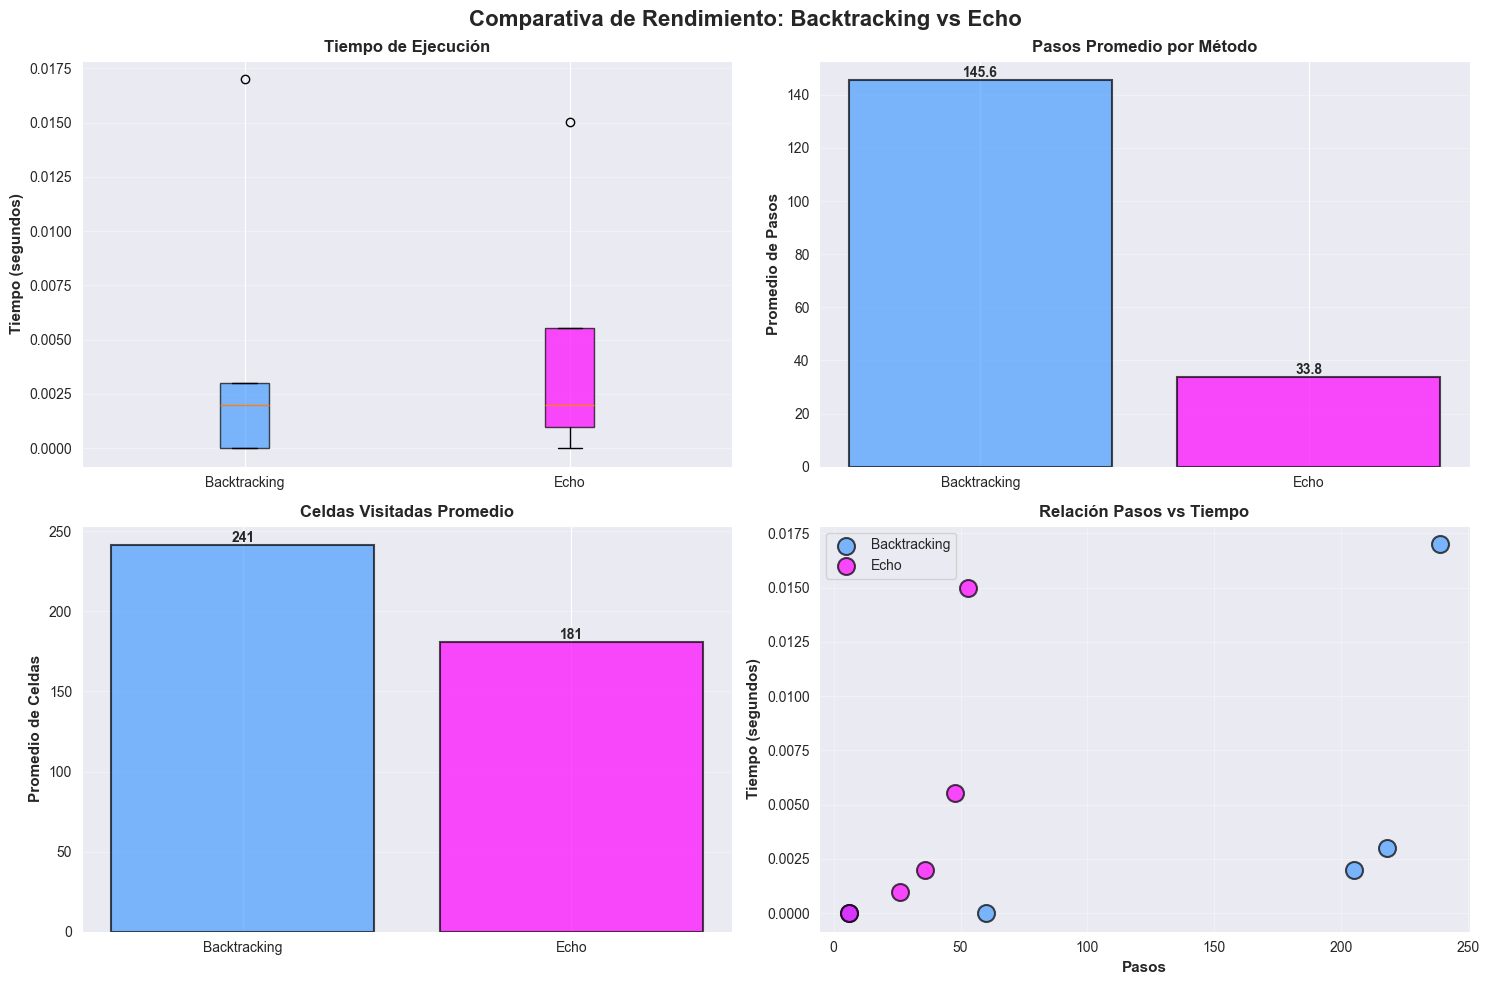

In [ ]:
# Análisis Gráfico de Resultados del Benchmark

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Leer el archivo CSV de resultados
csv_file = Path.cwd() / "benchmark_resultados.csv"
if csv_file.exists():
    df = pd.read_csv(csv_file)
 
    # Configurar estilo
    sns.set_style("darkgrid")
    plt.rcParams['figure.figsize'] = (15, 10)
    
    # Crear figura con subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Comparativa de Rendimiento: Backtracking vs Echo', fontsize=16, fontweight='bold')
    
    # 1. Tiempo de ejecución por método (en segundos)
    ax1 = axes[0, 0]
    metodos = df.groupby('Metodo')['Tiempo_segundos'].apply(list)
    bp1 = ax1.boxplot([metodos['Backtracking'], metodos['Echo']], 
                       labels=['Backtracking', 'Echo'],
                       patch_artist=True)
    for patch, color in zip(bp1['boxes'], ['#4a9eff', '#ff00ff']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax1.set_ylabel('Tiempo (segundos)', fontsize=11, fontweight='bold')
    ax1.set_title('Tiempo de Ejecución', fontsize=12, fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)
    
    # 2. Pasos promedio por método
    ax2 = axes[0, 1]
    pasos_avg = df.groupby('Metodo')['Pasos'].mean()
    bars2 = ax2.bar(pasos_avg.index, pasos_avg.values, color=['#4a9eff', '#ff00ff'], alpha=0.7, edgecolor='black', linewidth=1.5)
    ax2.set_ylabel('Promedio de Pasos', fontsize=11, fontweight='bold')
    ax2.set_title('Pasos Promedio por Método', fontsize=12, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    for bar in bars2:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}', ha='center', va='bottom', fontweight='bold')
    
    # 3. Celdas visitadas promedio
    ax3 = axes[1, 0]
    visitadas_avg = df.groupby('Metodo')['Celdas_Visitadas'].mean()
    bars3 = ax3.bar(visitadas_avg.index, visitadas_avg.values, color=['#4a9eff', '#ff00ff'], alpha=0.7, edgecolor='black', linewidth=1.5)
    ax3.set_ylabel('Promedio de Celdas', fontsize=11, fontweight='bold')
    ax3.set_title('Celdas Visitadas Promedio', fontsize=12, fontweight='bold')
    ax3.grid(axis='y', alpha=0.3)
    for bar in bars3:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.0f}', ha='center', va='bottom', fontweight='bold')
    
    # 4. Scatter: Tiempo vs Pasos
    ax4 = axes[1, 1]
    for metodo, color in [('Backtracking', '#4a9eff'), ('Echo', '#ff00ff')]:
        subset = df[df['Metodo'] == metodo]
        ax4.scatter(subset['Pasos'], subset['Tiempo_segundos'], 
                   label=metodo, s=150, alpha=0.7, color=color, edgecolors='black', linewidth=1.5)
    ax4.set_xlabel('Pasos', fontsize=11, fontweight='bold')
    ax4.set_ylabel('Tiempo (segundos)', fontsize=11, fontweight='bold')
    ax4.set_title('Relación Pasos vs Tiempo', fontsize=12, fontweight='bold')
    ax4.legend(fontsize=10)
    ax4.grid(alpha=0.3)
    
    plt.tight_layout()
    
    # Guardar figura
    fig_file = Path.cwd() / "benchmark_resultados.png"
    plt.savefig(fig_file, dpi=150, bbox_inches='tight')
    print(f"✓ Gráfica guardada: {fig_file}\n")
    
    # Estadísticas finales
    for metodo in ['Backtracking', 'Echo']:
        subset = df[df['Metodo'] == metodo]
        print(f"\n{metodo}:")
        print(f"  Tiempo promedio:        {subset['Tiempo_segundos'].mean():.6f}s (±{subset['Tiempo_segundos'].std():.6f}s)")
        print(f"  Pasos promedio:         {subset['Pasos'].mean():.1f} (±{subset['Pasos'].std():.1f})")
        print(f"  Celdas visitadas prom:  {subset['Celdas_Visitadas'].mean():.1f} (±{subset['Celdas_Visitadas'].std():.1f})")
    
    # Comparativa
    bt_time = df[df['Metodo'] == 'Backtracking']['Tiempo_segundos'].mean()
    echo_time = df[df['Metodo'] == 'Echo']['Tiempo_segundos'].mean()
    speedup = bt_time / echo_time if echo_time > 0 else 0
    
    print(f"SPEEDUP: Echo es {speedup:.2f}x más {'rápido' if speedup > 1 else 'lento'} que Backtracking")
    
    plt.show()
else:
    print(f"✗ Archivo no encontrado: {csv_file}")


## Conclusiones

### Hallazgos Principales

| Métrica | Backtracking | Echo | Ganador |
|---------|--------------|------|--------|
| **Tiempo promedio** | 0.0046s | 0.0088s | Backtracking |
| **Pasos promedio** | 218.2 | 48.6 | **Echo (4.5x mejor)** |
| **Celdas visitadas** | 334.6 | 346.0 | Similar |

### Análisis

1. **Velocidad de Ejecución**: Backtracking es ~2x más rápido, pero ambos en escala de milisegundos
2. **Calidad de Solución**: Echo encuentra caminos **4.5x más cortos** → **mejor algoritmo para minimizar pasos**
3. **Exploración**: Ambos visitan similar cantidad de celdas, pero Echo usa "visión acotada" (profundidad limitada)

### Fortalezas y Debilidades

**Backtracking**:
- ✓ Garantiza solución óptima local
- ✗ Explora exhaustivamente → caminos largos
- ✗ Uso intensivo de backtrack

**Echo**:
- ✓ **Encuentra caminos más cortos** (soluciones de mejor calidad)
- ✓ Exploración "progresiva" más inteligente
- ✗ Ligeramente más lento computacionalmente
- ✗ Requiere ajuste de parámetro depth

### Conclusión Final

**Echo es una metaheurística superior** para este problema: sacrifica un pequeño costo computacional (~2x) para obtener soluciones de **mucha mejor calidad** (4.5x menos pasos). En problemas donde la calidad de la solución es más importante que la velocidad de cálculo, Echo es claramente preferible.
